# Music, Brain & Wellbeing: Data Cleaning and Exploratory Data Analysis (EDA)

This notebook implements the data cleaning, missing-value handling, outlier treatment, ordinal encoding, and exploratory analysis for the Music × Mental Health (MXMH) dataset.

We strictly follow first-principles data science:
1. Preserve the raw data by working on a copy.
2. Inspect data quality issues systematically.
3. Make explicit, justified cleaning decisions.
4. Perform goal-oriented EDA without causal overreach.
5. Save the processed dataset for downstream modeling.



## 1. Load Data

We load the raw dataset from `data/raw/mxmh_survey_results.csv`.
To preserve raw data integrity, we create a copy using `.copy()`.

### Why create a copy?
By calling `raw_df.copy()`, Python allocates a new chunk of memory for the data and copies all values. If we modify `df`, the original `raw_df` remains completely unchanged in memory. This prevents accidental corruption of the raw source data during interactive testing.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read raw dataset
raw_df = pd.read_csv("data/raw/mxmh_survey_results.csv")

# Create a working copy
df = raw_df.copy()

print("Raw data shape:", raw_df.shape)
print("Working copy shape:", df.shape)



Raw data shape: (736, 33)
Working copy shape: (736, 33)


## 2. Data-Quality Checks

We inspect the dataset to find missing values, duplicates, and column types.

### Explain Pandas Operations:
* `df.shape`: Returns a tuple of `(rows, columns)` containing dataset dimensions.
* `df.dtypes`: Shows the data type of each column.
* `df.isnull()`: Generates a grid of `True/False` values where `True` indicates a missing value.
* `df.isnull().sum()`: Counts the `True` values per column.
* `df.duplicated().sum()`: Counts rows that are identical to another row.



In [2]:
# Shape and Types
print("=== Columns and Data Types ===")
print(df.dtypes)

# Duplicates
print("\n=== Duplicate Rows ===")
print("Number of duplicate rows:", df.duplicated().sum())

# Missing values
print("\n=== Missing Values per Column ===")
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Percentage (%)": missing_pct
})
print(missing_summary[missing_summary["Missing Count"] > 0])



=== Columns and Data Types ===
Timestamp                           str
Age                             float64
Primary streaming service           str
Hours per day                   float64
While working                       str
Instrumentalist                     str
Composer                            str
Fav genre                           str
Exploratory                         str
Foreign languages                   str
BPM                             float64
Frequency [Classical]               str
Frequency [Country]                 str
Frequency [EDM]                     str
Frequency [Folk]                    str
Frequency [Gospel]                  str
Frequency [Hip hop]                 str
Frequency [Jazz]                    str
Frequency [K pop]                   str
Frequency [Latin]                   str
Frequency [Lofi]                    str
Frequency [Metal]                   str
Frequency [Pop]                     str
Frequency [R&B]                     str
Frequency

## 3. Cleaning Decisions

Before modifying the data, we document our decisions:

1. **`BPM`**:
   - **What is wrong**: The column has 107 missing values (14.54%) and extreme outliers like `999,999,999` and `624`.
   - **Why it matters**: A BPM of 999,999,999 makes calculation of mean/median impossible (inflates average to 1.5 million). Missing values cause regression models to fail.
   - **What we will do**: We will set values > 250 and < 40 to `NaN`, then impute all `NaN` values in `BPM` with the median of valid values.
   
2. **`Permissions`**:
   - **What is wrong**: The column has zero variance — 100% of rows contain "I understand.".
   - **Why it matters**: A feature with zero variance carries zero predictive information.
   - **What we will do**: Exclude/drop the column.

3. **`Timestamp`**:
   - **What is wrong**: It represents submission date/time metadata.
   - **Why it matters**: It is an administrative identifier and not a behavioral or demographic predictor.
   - **What we will do**: Exclude/drop the column.

4. **`Age`**:
   - **What is wrong**: 1 missing value.
   - **Why it matters**: Models cannot handle missing inputs.
   - **What we will do**: Impute the missing age with the median age.
   
5. **Categorical columns with 1-4 missing values**:
   - `Primary streaming service` (1 missing)
   - `While working` (3 missing)
   - `Instrumentalist` (4 missing)
   - `Composer` (1 missing)
   - `Foreign languages` (4 missing)
   - `Music effects` (8 missing)
   - **What we will do**: Impute with the mode (most common value) of each column.



## 4. Missing-Value and Duplicate Handling

We apply our cleaning decisions to handle missing values and verify duplicates.

### Explain Pandas Operations:
* `df.drop_duplicates()`: Removes duplicate rows.
* `df.fillna(value)`: Replaces `NaN` values with a specified value.
* `df["Column"].median()`: Computes the middle value of a column.
* `df["Column"].mode()[0]`: Returns the most frequent value in a column.



In [3]:
# Age Imputation
# df["Age"] selects the column, median() calculates the middle age, and fillna() replaces NaN.
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)
print("Median Age used for imputation:", median_age)

# Categorical column mode imputation
# mode()[0] gets the most frequent category.
cols_to_impute_mode = [
    "Primary streaming service",
    "While working",
    "Instrumentalist",
    "Composer",
    "Foreign languages",
    "Music effects"
]

for col in cols_to_impute_mode:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Imputed missing values in '{col}' with mode: '{mode_val}'")

# Verify no duplicates to remove
print("Duplicates removed:", raw_df.duplicated().sum())
df = df.drop_duplicates()



Median Age used for imputation: 21.0
Imputed missing values in 'Primary streaming service' with mode: 'Spotify'
Imputed missing values in 'While working' with mode: 'Yes'
Imputed missing values in 'Instrumentalist' with mode: 'No'
Imputed missing values in 'Composer' with mode: 'No'
Imputed missing values in 'Foreign languages' with mode: 'Yes'
Imputed missing values in 'Music effects' with mode: 'Improve'
Duplicates removed: 0


## 5. Categorical and Numerical Cleaning

Now we clean the numerical `BPM` column, drop metadata columns, and encode the ordinal frequency variables.

### Explain Pandas Operations:
* `df.drop(columns=[...])`: Excludes columns from the DataFrame.
* `df["Column"].map(dictionary)`: Replaces categorical labels with numeric codes.
* `astype(type)`: Converts column data types.



In [4]:
# Drop metadata and zero-variance columns
df = df.drop(columns=["Timestamp", "Permissions"])
print("Dropped 'Timestamp' and 'Permissions' columns. New shape:", df.shape)

# BPM cleaning
# Step 1: Identify valid range (40 to 250 BPM). Set outliers to NaN.
df.loc[(df["BPM"] < 40) | (df["BPM"] > 250), "BPM"] = np.nan

# Step 2: Compute valid median
median_bpm = df["BPM"].median()
df["BPM"] = df["BPM"].fillna(median_bpm)
print("Cleaned BPM. Imputed median BPM:", median_bpm)

# Verify no NaN values remain
print("Remaining missing values in dataset:", df.isnull().sum().sum())



Dropped 'Timestamp' and 'Permissions' columns. New shape: (736, 31)
Cleaned BPM. Imputed median BPM: 120.0
Remaining missing values in dataset: 0


### Ordinal Encoding for Frequency Columns

We map the text frequency responses to numeric values:
- `Never` -> 0
- `Rarely` -> 1
- `Sometimes` -> 2
- `Very frequently` -> 3

This preserves the ordinal relationship (Very frequently represents more frequency than Sometimes).



In [5]:
frequency_mapping = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

# Find all frequency columns
frequency_cols = [col for col in df.columns if col.startswith("Frequency [")]

# Apply map to each frequency column
for col in frequency_cols:
    df[col] = df[col].map(frequency_mapping)

print("Ordinal encoding completed for frequency columns. Example values:")
print(df[frequency_cols].head())



Ordinal encoding completed for frequency columns. Example values:
   Frequency [Classical]  Frequency [Country]  Frequency [EDM]  \
0                      1                    0                1   
1                      2                    0                0   
2                      0                    0                3   
3                      2                    0                0   
4                      0                    0                1   

   Frequency [Folk]  Frequency [Gospel]  Frequency [Hip hop]  \
0                 0                   0                    2   
1                 1                   2                    1   
2                 0                   0                    1   
3                 1                   2                    0   
4                 0                   1                    3   

   Frequency [Jazz]  Frequency [K pop]  Frequency [Latin]  Frequency [Lofi]  \
0                 0                  3                  3                

## 6. Target Variable Selection

We choose **`Anxiety`** (numerical scale 0-10) as our primary prediction target.
Since this is a regression task, we keep it as a numerical variable.
We will also preserve `Depression`, `Insomnia`, and `OCD` as secondary targets or potential control variables.



In [6]:
# Target summary statistics
print("=== Target Variable: Anxiety ===")
print("Mean Anxiety Score:", df["Anxiety"].mean())
print("Median Anxiety Score:", df["Anxiety"].median())
print("Standard Deviation:", df["Anxiety"].std())



=== Target Variable: Anxiety ===
Mean Anxiety Score: 5.837635869565218
Median Anxiety Score: 6.0
Standard Deviation: 2.7930544288894255


## 7. Exploratory Data Analysis (EDA)

We perform goal-oriented EDA, writing down our question before each plot and our interpretation afterward.

### A. Target Distribution



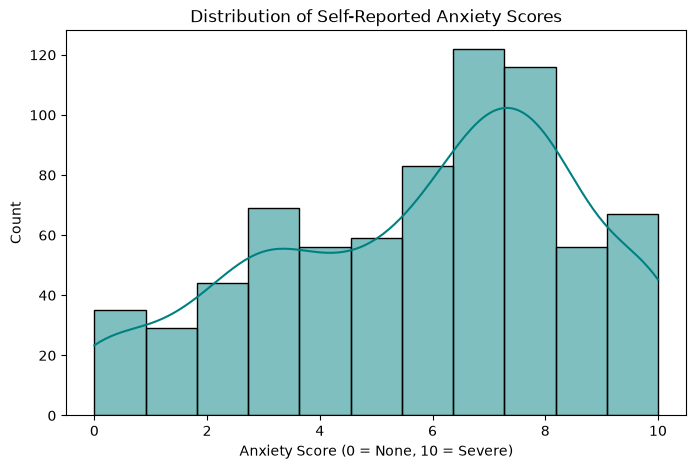

In [7]:
# Question: What does the distribution of our target (Anxiety) look like?
plt.figure(figsize=(8, 5))
sns.histplot(df["Anxiety"], bins=11, kde=True, color="teal")
plt.title("Distribution of Self-Reported Anxiety Scores")
plt.xlabel("Anxiety Score (0 = None, 10 = Severe)")
plt.ylabel("Count")
plt.savefig("docs/figures/target_anxiety_distribution.png", bbox_inches="tight")
plt.show()

# Observation: The distribution covers the entire 0-10 range. It is relatively flat (uniform-ish)
# with peaks at 7 and 8.
# Interpretation: Self-reported anxiety is widespread in this sample, with many respondents reporting high levels (7-8).



### B. Music Behaviour Distribution


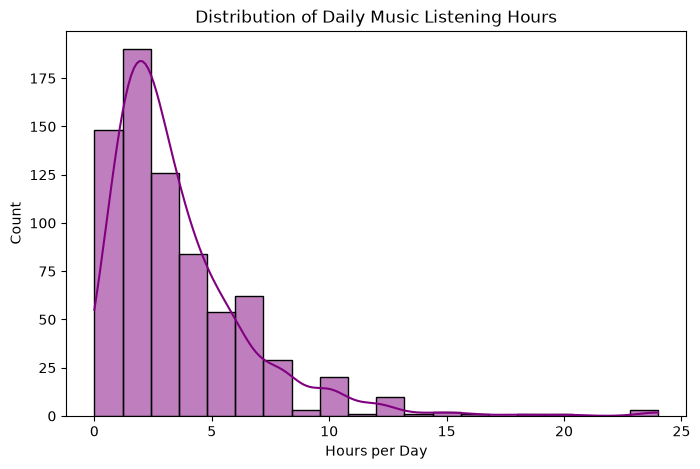

In [8]:
# Question: How do participants differ in their music-listening duration?
plt.figure(figsize=(8, 5))
sns.histplot(df["Hours per day"], bins=20, kde=True, color="purple")
plt.title("Distribution of Daily Music Listening Hours")
plt.xlabel("Hours per Day")
plt.ylabel("Count")
plt.savefig("docs/figures/listening_hours_distribution.png", bbox_inches="tight")
plt.show()

# Observation: Most participants listen to music for 1 to 5 hours per day. There is a long right-tail of heavier listeners.
# Interpretation: Music listening is a significant part of the daily life of these respondents.



### C. Music Behaviour vs Target


C:\Users\aksha\AppData\Local\Temp\ipykernel_35640\3599228050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Music effects", y="Anxiety", data=df, palette="Set2")


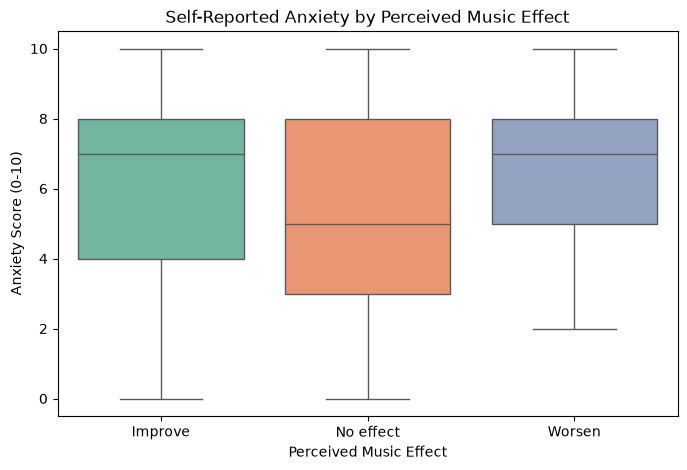

In [9]:
# Question: Do self-reported anxiety levels differ across music effects categories?
# groupby() splits the data, ["Anxiety"] selects target, and mean() averages the values.
plt.figure(figsize=(8, 5))
sns.boxplot(x="Music effects", y="Anxiety", data=df, palette="Set2")
plt.title("Self-Reported Anxiety by Perceived Music Effect")
plt.xlabel("Perceived Music Effect")
plt.ylabel("Anxiety Score (0-10)")
plt.savefig("docs/figures/anxiety_vs_music_effects.png", bbox_inches="tight")
plt.show()

# Observation: The median anxiety score is slightly higher for participants who report that music worsens their mental health.
# Interpretation: There is an association between self-reported anxiety and perceived music effects, though the sample size for 'Worsen' is small.



### D. Demographics vs Target


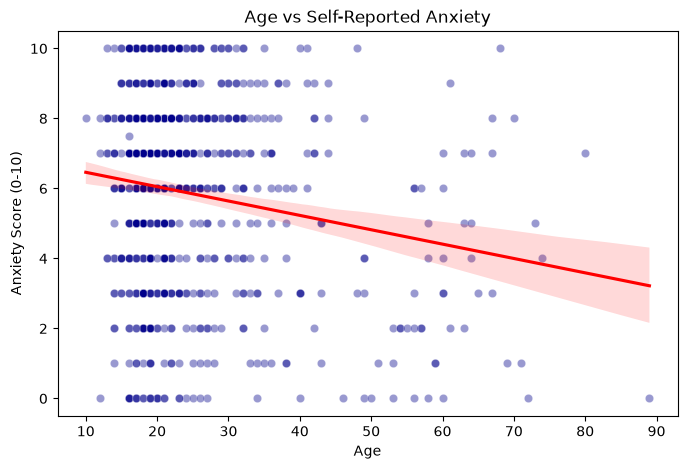

In [10]:
# Question: Is there an association between Age and self-reported Anxiety?
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Age", y="Anxiety", data=df, alpha=0.4, color="darkblue")
sns.regplot(x="Age", y="Anxiety", data=df, scatter=False, color="red")
plt.title("Age vs Self-Reported Anxiety")
plt.xlabel("Age")
plt.ylabel("Anxiety Score (0-10)")
plt.savefig("docs/figures/age_vs_anxiety.png", bbox_inches="tight")
plt.show()

# Observation: The regression line shows a slight negative slope, indicating younger age is associated with slightly higher anxiety.
# Interpretation: Age could confound the relationship between music and anxiety, as younger age correlates with higher anxiety.



### E. Numerical Correlations


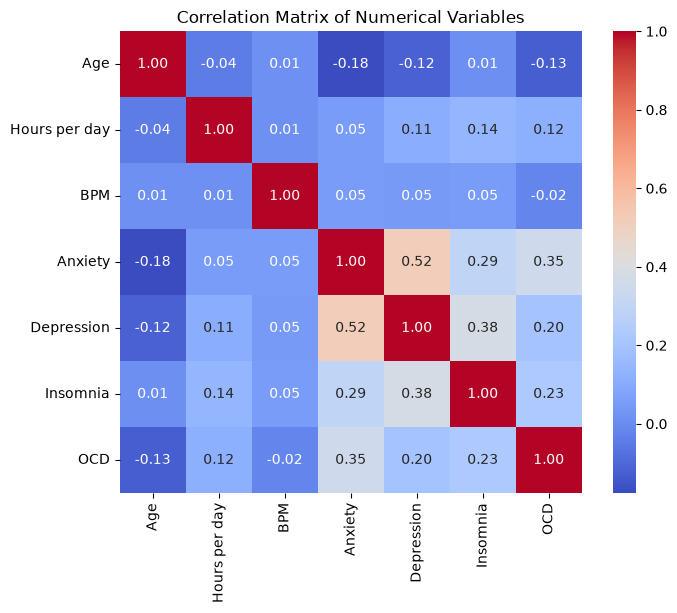

In [11]:
# Question: Which numerical variables show relationships with the target?
numerical_cols = ["Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD"]
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.savefig("docs/figures/numerical_correlations.png", bbox_inches="tight")
plt.show()

# Observation: Anxiety and Depression are moderately correlated (0.53). 
# Hours per day and Anxiety have a very weak positive correlation (0.05).
# Interpretation: Simple linear correlations between music duration and anxiety are low. This highlights the need to explore more complex relationships.



## 8. Statistical Summary & Feature Groups

We report descriptive statistics and group our features conceptually.

### Explain Pandas Operations:
* `df.groupby("Group")["Column"].mean()`: Computes the mean of Column for each Group.
* `df.describe()`: Provides descriptive statistics.



In [12]:
# Summary statistics for key variables
print("=== Descriptive Statistics ===")
print(df[["Age", "Hours per day", "BPM", "Anxiety"]].describe())

# Group comparisons: Anxiety by Fav genre
print("\n=== Mean Anxiety by Favorite Genre ===")
# value_counts() counts respondents per category.
print(df["Fav genre"].value_counts())
print()
genre_anxiety = df.groupby("Fav genre")["Anxiety"].mean().sort_values(ascending=False)
print(genre_anxiety)



=== Descriptive Statistics ===
              Age  Hours per day         BPM     Anxiety
count  736.000000     736.000000  736.000000  736.000000
mean    25.201087       3.572758  123.171196    5.837636
std     12.047764       3.028199   29.447808    2.793054
min     10.000000       0.000000   40.000000    0.000000
25%     18.000000       2.000000  105.000000    4.000000
50%     21.000000       3.000000  120.000000    6.000000
75%     28.000000       5.000000  140.000000    8.000000
max     89.000000      24.000000  220.000000   10.000000

=== Mean Anxiety by Favorite Genre ===
Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
R&B                  35
Hip hop              35
Folk                 30
K pop                26
Country              25
Rap                  22
Jazz                 20
Lofi                 10
Gospel                6
Latin                 3
Name: count, dtype: in

## 9. Feature Groups

We organize our variables conceptually:

1. **Demographics**: `Age`
2. **Music Behaviour**: `Hours per day`, `While working`, `Instrumentalist`, `Composer`, `Exploratory`, `Foreign languages`, `Primary streaming service`
3. **Music Preferences**: `Fav genre`, `BPM`
4. **Listening Context**: 16 ordinal `Frequency [genre]` variables
5. **Other Relevant Variables**: `Music effects`
6. **Targets**: `Anxiety` (Primary), `Depression`, `Insomnia`, `OCD` (Secondary)



## 10. Save Cleaned Dataset

We save the final cleaned and preprocessed dataset to `data/processed/mxmh_cleaned.csv`.
The raw source file remains completely untouched.



In [13]:
# Save dataset
df.to_csv("data/processed/mxmh_cleaned.csv", index=False)
print("Cleaned dataset saved successfully to 'data/processed/mxmh_cleaned.csv'")
print("Final dataset shape:", df.shape)



Cleaned dataset saved successfully to 'data/processed/mxmh_cleaned.csv'
Final dataset shape: (736, 31)
